# Laboratorium 5: Zespoły klasyfikatorów
**RF · AdaBoost · LightGBM · XGBoost**

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import lightgbm as lgb
import xgboost as xgb
import shap

#warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.float_format', '{:.4f}'.format)
shap.initjs()

## 1. Sanity check — zbiór GLASS

In [ ]:
glass = fetch_ucirepo(id=42)
X_glass = glass.data.features.values
y_glass = glass.data.targets.values.ravel()

le_glass = LabelEncoder()
y_glass = le_glass.fit_transform(y_glass)

X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_glass, y_glass, test_size=0.2, stratify=y_glass
)
print(f'Train: {X_tr_g.shape}, Test: {X_te_g.shape}')
print(f'Klasy: {np.unique(y_glass)}')


Train: (171, 9), Test: (43, 9)
Klasy: [0 1 2 3 4 5]


In [ ]:
def eval_clf(name, clf, X_tr, y_tr, X_te, y_te, avg='macro'):
    clf.fit(X_tr, y_tr)
    yp_tr = clf.predict(X_tr)
    yp_te = clf.predict(X_te)
    return {
        'Model':     name,
        'Acc Train': accuracy_score(y_tr, yp_tr),
        'Acc Test':  accuracy_score(y_te, yp_te),
        'Bal.Acc':   balanced_accuracy_score(y_te, yp_te),
        'F1 macro':  f1_score(y_te, yp_te, average=avg, zero_division=0),
    }

glass_models = [
    ('RandomForest',  RandomForestClassifier()),
    ('AdaBoost',      AdaBoostClassifier()),
    ('LightGBM',      lgb.LGBMClassifier(verbose=-1)),
    ('XGBoost',       xgb.XGBClassifier(verbosity=0, eval_metric='mlogloss')),
    ('DecisionTree',  DecisionTreeClassifier()),
]

glass_results = [eval_clf(n, m, X_tr_g, y_tr_g, X_te_g, y_te_g) for n, m in glass_models]
df_glass = pd.DataFrame(glass_results).set_index('Model')
display(df_glass.round(4))


,Acc Train,Acc Test,Bal.Acc,F1 macro
Model,,,,
RandomForest,1.0000,0.7907,0.8103,0.7868
AdaBoost,0.4561,0.4884,0.3786,0.4152
LightGBM,1.0000,0.8605,0.9151,0.8497
XGBoost,1.0000,0.8140,0.8643,0.8079
DecisionTree,1.0000,0.6977,0.6921,0.6542


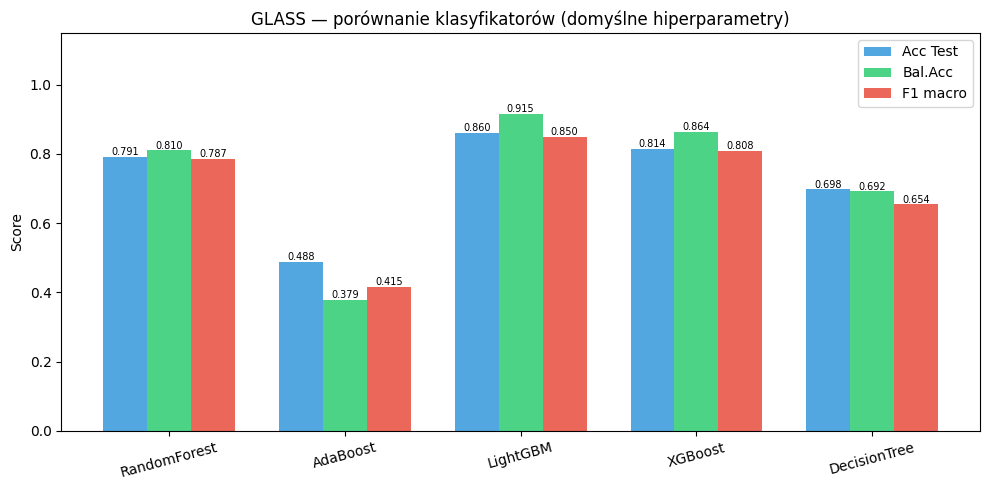

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_glass))
width = 0.25
for i, (col, color) in enumerate([
    ('Acc Test', '#3498db'), ('Bal.Acc', '#2ecc71'), ('F1 macro', '#e74c3c')
]):
    bars = ax.bar(x + (i - 1) * width, df_glass[col], width, label=col, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(df_glass.index, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('GLASS — porównanie klasyfikatorów (domyślne hiperparametry)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Hospital Readmissions — EDA

In [ ]:
hosp = fetch_ucirepo(id=296)
df_raw = hosp.data.features.copy()
df_raw['readmitted'] = hosp.data.targets['readmitted'].values
print(f'Rozmiar: {df_raw.shape}')
print(f'Kolumny target: {df_raw["readmitted"].unique()}')

Rozmiar: (101766, 48)
Kolumny target: <StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str


/Users/mikolajolesinski/Desktop/uczenie_maszynowe/listy/.venv/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [ ]:
df = df_raw.copy()
df['target'] = (df['readmitted'] == '<30').astype(int)

print('Rozkład targetu:')
vc = df['target'].value_counts()
print(vc)
print(f'Odsetek <30 dni: {vc[1] / len(df) * 100:.1f}%')

Rozkład targetu:
target
0    90409
1    11357
Name: count, dtype: int64
Odsetek <30 dni: 11.2%


In [ ]:
print(f'Kształt: {df_raw.shape}')
print(f'\nTypy danych:')
display(pd.DataFrame({
    'dtype': df_raw.dtypes,
    'nulls': df_raw.isnull().sum() + (df_raw == '?').sum(),
    'nulls_%': ((df_raw.isnull().sum() + (df_raw == '?').sum()) / len(df_raw) * 100).round(1),
    'unique': df_raw.nunique(),
    'example': df_raw.iloc[0],
}).sort_values('nulls_%', ascending=False))

Kształt: (101766, 48)

Typy danych:


,dtype,nulls,nulls_%,unique,example
weight,str,98569,96.9000,9,NaN
max_glu_serum,str,96420,94.7000,3,NaN
A1Cresult,str,84748,83.3000,3,NaN
medical_specialty,str,49949,49.1000,72,Pediatrics-Endocrinology
payer_code,str,40256,39.6000,17,NaN
race,str,2273,2.2000,5,Caucasian
diag_3,str,1423,1.4000,789,NaN
diag_2,str,358,0.4000,748,NaN
tolazamide,str,0,0.0000,3,No
tolbutamide,str,0,0.0000,2,No


## Co oznaczają kolumny

**Demograficzne**
- `race` — rasa pacjenta (Caucasian, AfricanAmerican, Hispanic, Asian, Other)
- `gender` — płeć (Female, Male, Unknown/Invalid)
- `age` — wiek w przedziałach dekadowych: [0-10), [10-20), ..., [90-100)

**Przebieg hospitalizacji**
- `time_in_hospital` — liczba dni spędzonych w szpitalu (1–14)
- `num_lab_procedures` — liczba wykonanych badań laboratoryjnych
- `num_procedures` — liczba zabiegów innych niż laboratoryjne
- `num_medications` — liczba różnych leków podanych podczas wizyty
- `number_diagnoses` — liczba diagnoz postawionych podczas wizyty

**Historia pacjenta (rok przed wizytą)**
- `number_inpatient` — liczba poprzednich hospitalizacji
- `number_outpatient` — liczba wizyt ambulatoryjnych
- `number_emergency` — liczba wizyt na izbie przyjęć

**Diagnozy**
- `diag_1` — diagnoza główna (kod ICD-9, ~700 unikalnych)
- `diag_2` — diagnoza dodatkowa
- `diag_3` — diagnoza trzeciorzędna

**Wyniki badań**
- `A1Cresult` — wynik testu HbA1c (hemoglobina glikowana — marker poziomu cukru)
- `max_glu_serum` — maksymalny poziom glukozy w surowicy podczas wizyty

**Administracyjne**
- `admission_type_id` — tryb przyjęcia (nagły, planowy, noworodek itd.)
- `discharge_disposition_id` — sposób wypisu (do domu, do innej placówki, zgon itd.)
- `admission_source_id` — źródło skierowania (izba przyjęć, lekarz, transfer itd.)

**Leki (23 kolumny)**
- Każda kolumna to jeden lek przeciwcukrzycowy (np. `metformin`, `insulin`, `glipizide`)
- Wartości: `No` / `Steady` (bez zmiany) / `Up` (zwiększono dawkę) / `Down` (zmniejszono)
- `change` — czy w ogóle zmieniono jakikolwiek lek podczas wizyty
- `diabetesMed` — czy przepisano jakikolwiek lek przeciwcukrzycowy

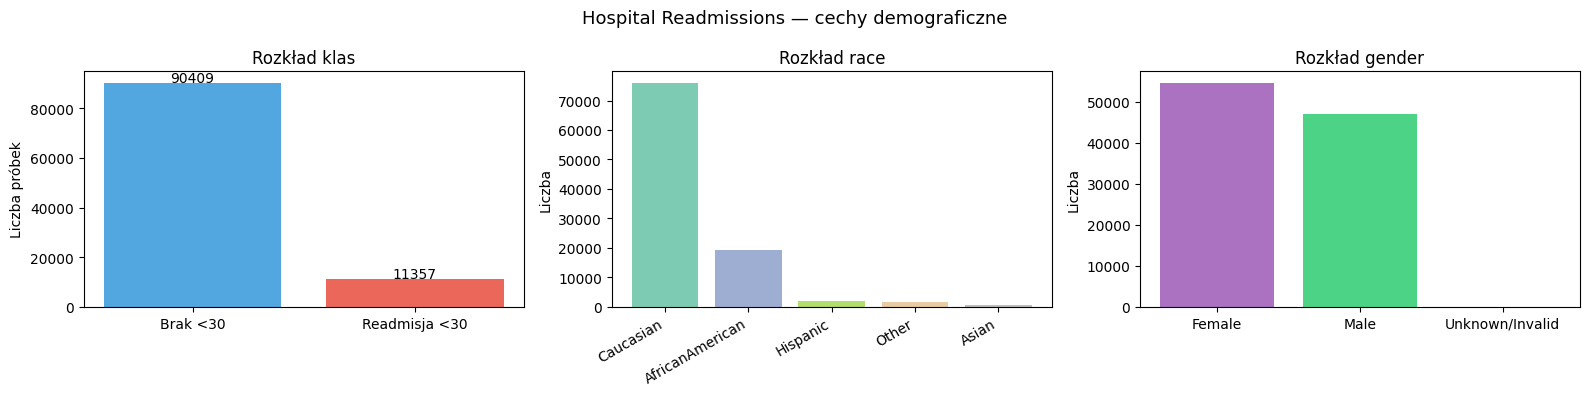

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(['Brak <30', 'Readmisja <30'], vc.values, color=['#3498db', '#e74c3c'], alpha=0.85)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 200, str(v), ha='center')
axes[0].set_title('Rozkład klas')
axes[0].set_ylabel('Liczba próbek')

rc = df['race'].value_counts()
axes[1].bar(rc.index, rc.values, color=plt.cm.Set2(np.linspace(0, 1, len(rc))), alpha=0.85)
axes[1].set_title('Rozkład race')
axes[1].set_xticklabels(rc.index, rotation=30, ha='right')
axes[1].set_ylabel('Liczba')

gc = df['gender'].value_counts()
axes[2].bar(gc.index, gc.values, color=['#9b59b6', '#2ecc71'], alpha=0.85)
axes[2].set_title('Rozkład gender')
axes[2].set_ylabel('Liczba')

plt.suptitle('Hospital Readmissions — cechy demograficzne', fontsize=13)
plt.tight_layout()
plt.show()

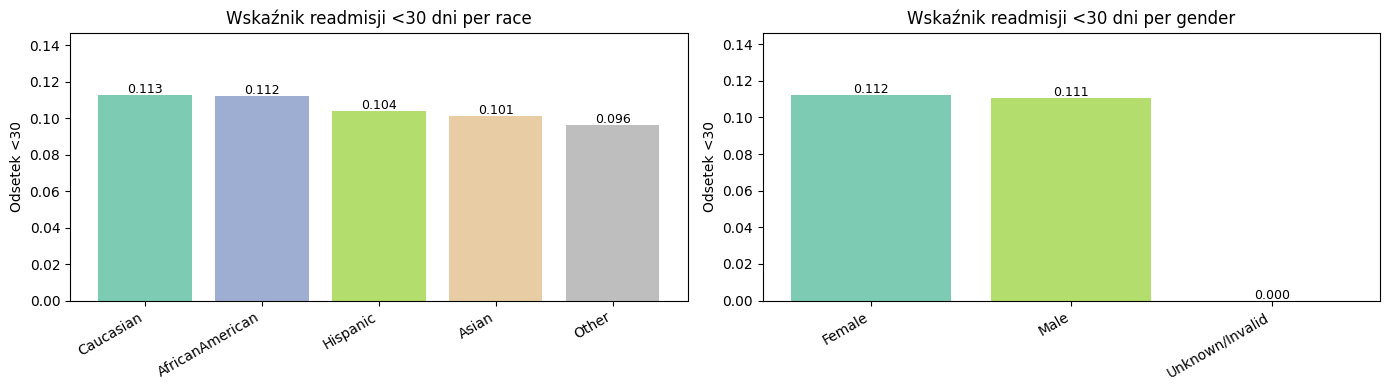

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['race', 'gender']):
    rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    ax.bar(rate.index, rate.values, color=plt.cm.Set2(np.linspace(0, 1, len(rate))), alpha=0.85)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)
    ax.set_title(f'Wskaźnik readmisji <30 dni per {col}')
    ax.set_ylabel('Odsetek <30')
    ax.set_xticklabels(rate.index, rotation=30, ha='right')
    ax.set_ylim(0, rate.max() * 1.3)

plt.tight_layout()
plt.show()

In [ ]:
missing = (df == '?').sum() + df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Kolumny z brakującymi danymi:')
print(missing)

Kolumny z brakującymi danymi:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [ ]:
SENSITIVE_COLS = ['race', 'gender', 'age']
DROP_COLS = ['readmitted', 'target', 'encounter_id', 'patient_nbr',
             'weight', 'payer_code', 'medical_specialty']

df_prep = df.copy()
df_prep = df_prep.replace('?', np.nan)

df_sensitive = df_prep[SENSITIVE_COLS].copy()

feat_cols = [c for c in df_prep.columns if c not in DROP_COLS]
X_all = df_prep[feat_cols].copy()
y_all = df['target'].values

cat_cols = X_all.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    X_all[col] = le.fit_transform(X_all[col].astype(str))

X_all = X_all.values.astype(float)

X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_all, y_all, np.arange(len(y_all)),
    test_size=0.2, stratify=y_all,
)

imputer = SimpleImputer(strategy='median')
X_tr = imputer.fit_transform(X_tr)
X_te = imputer.transform(X_te)

df_sens_te = df_sensitive.iloc[idx_te].reset_index(drop=True)

print(f'Train: {X_tr.shape}, Test: {X_te.shape}')
print(f'Readmisja <30 train: {y_tr.sum()} ({100*y_tr.mean():.1f}%)')
print(f'Readmisja <30 test:  {y_te.sum()} ({100*y_te.mean():.1f}%)')

/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_63663/42034344.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_all.select_dtypes(include='object').columns.tolist()


Train: (81412, 44), Test: (20354, 44)
Readmisja <30 train: 9086 (11.2%)
Readmisja <30 test:  2271 (11.2%)


## Preprocessing — decyzje

### Usunięte kolumny (`DROP_COLS`)
| Kolumna | Powód |
|---|---|
| `readmitted`, `target` | Target — odpowiedź modelu, nie cecha |
| `encounter_id`, `patient_nbr` | Identyfikatory bez wartości predykcyjnej |
| `weight` | 98 569 brakujących (~97% danych) |
| `payer_code` | 40 256 brakujących (~40%), niska wartość kliniczna |
| `medical_specialty` | 49 949 brakujących (~49%) |

### Pozostałe braki danych
Kolumny `max_glu_serum`, `A1Cresult`, `race`, `diag_1/2/3` mają braki imputowane medianą
(fit tylko na zbiorze treningowym — brak data leakage).

### Kodowanie kategoryczne
Zmienne tekstowe (race, gender, age, diagnozy) zakodowane przez `LabelEncoder`.
Drzewa nie wymagają one-hot encoding.

### Podział
80/20 stratyfikowany — obie części zachowują proporcję 11.2% readmisji `<30`.

## 3. Hiperparametry

In [ ]:
def sweep_param(model_fn, param_name, param_values, X_tr, y_tr, X_te, y_te,
                scoring='recall', n_splits=5):
    """Sweep jednego hiperparametru z CV, zwraca DataFrame wyników."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
    rows = []
    for val in tqdm(param_values, desc=param_name):
        clf = model_fn(**{param_name: val})
        clf.fit(X_tr, y_tr)
        yp_tr = clf.predict(X_tr)
        yp_te = clf.predict(X_te)
        cv = cross_val_score(clf, X_tr, y_tr, cv=skf, scoring=scoring)
        rows.append({
            param_name:   val,
            'train_rec':  recall_score(y_tr, yp_tr, zero_division=0),
            'test_rec':   recall_score(y_te, yp_te, zero_division=0),
            'train_prec': precision_score(y_tr, yp_tr, zero_division=0),
            'test_prec':  precision_score(y_te, yp_te, zero_division=0),
            'test_f1':    f1_score(y_te, yp_te, zero_division=0),
            'cv_mean':    cv.mean(),
            'cv_std':     cv.std(),
        })
    return pd.DataFrame(rows).set_index(param_name)


def _coerce_index_value(val):
    import math
    if val is None:
        return None
    if isinstance(val, float):
        if math.isnan(val):
            return None
        if val == int(val):
            return int(val)
    if hasattr(val, 'item'):
        return val.item()
    return val


def plot_sweep(df_sw, param_name, title):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    best = _coerce_index_value(df_sw['cv_mean'].idxmax())
    idx_list = list(df_sw.index)
    x = np.arange(len(idx_list))
    xlabels = [str(v) for v in idx_list]

    # Position of the best value in the index
    try:
        best_pos = next(i for i, v in enumerate(idx_list)
                        if str(_coerce_index_value(v)) == str(best))
    except StopIteration:
        best_pos = 0

    for ax, pairs, ylabel, title_s in [
        (axes[0],
         [('train_rec', '#9b59b6', 'Recall (train)'),
          ('test_rec',  '#e74c3c', 'Recall (test)'),
          ('cv_mean',   '#3498db', 'CV mean recall', 's')],
         'Recall', f'Recall vs {param_name}'),
        (axes[1],
         [('train_prec', '#9b59b6', 'Precision (train)'),
          ('test_prec',  '#3498db', 'Precision (test)'),
          ('test_f1',    '#2ecc71', 'F1 (test)', 's')],
         'Score', f'Precision / F1 vs {param_name}'),
    ]:
        for item in pairs:
            col, color, label = item[0], item[1], item[2]
            marker = item[3] if len(item) > 3 else 'o'
            ax.plot(x, df_sw[col], color=color, marker=marker, markersize=4, label=label)
        if ylabel == 'Recall':
            ax.fill_between(x, df_sw['cv_mean'] - df_sw['cv_std'],
                               df_sw['cv_mean'] + df_sw['cv_std'],
                            alpha=0.2, color='#3498db')
        ax.axvline(best_pos, color='black', linestyle=':', label=f'optimum={best}')
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, rotation=30, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_xlabel(param_name)
        ax.set_title(title_s)
        ax.legend(fontsize=8)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    return best


### 3.1 Random Forest

n_estimators:   0%|          | 0/7 [00:00<?, ?it/s]

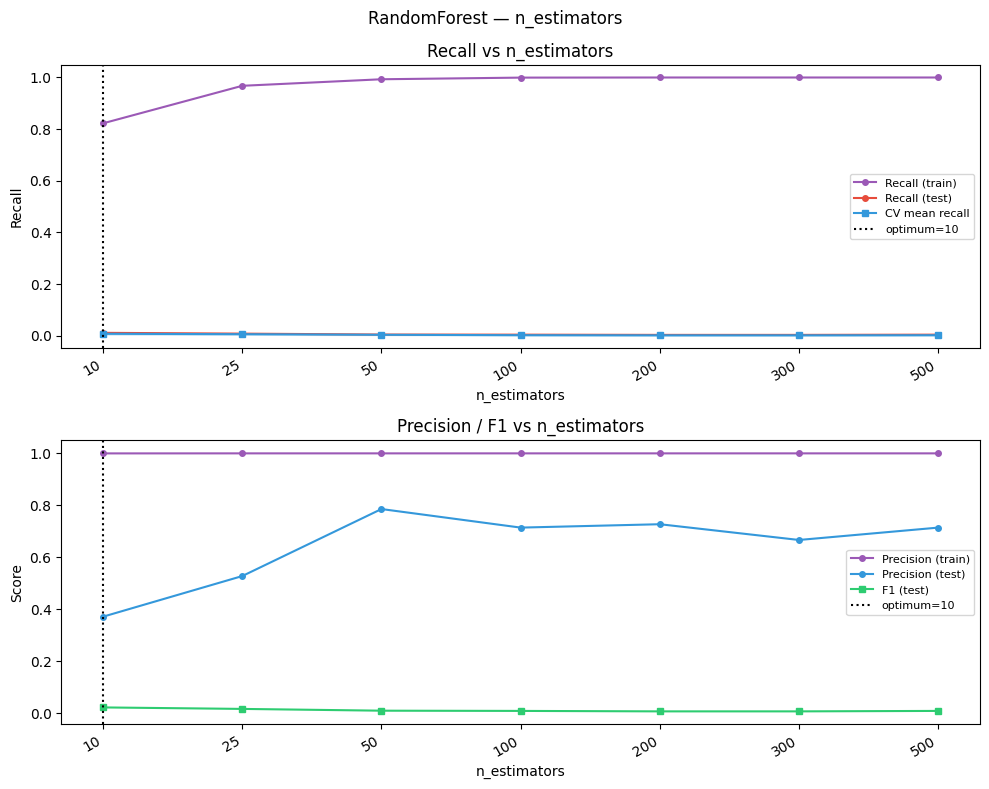

Najlepsze n_estimators: 10


In [ ]:
rf_fn = lambda **kw: RandomForestClassifier(class_weight='balanced', n_jobs=-1, **kw)

df_rf_n = sweep_param(rf_fn, 'n_estimators', [10, 25, 50, 100, 200, 300, 500],
                      X_tr, y_tr, X_te, y_te)
best_rf_n = plot_sweep(df_rf_n, 'n_estimators', 'RandomForest — n_estimators')
print(f'Najlepsze n_estimators: {best_rf_n}')

max_depth:   0%|          | 0/6 [00:00<?, ?it/s]

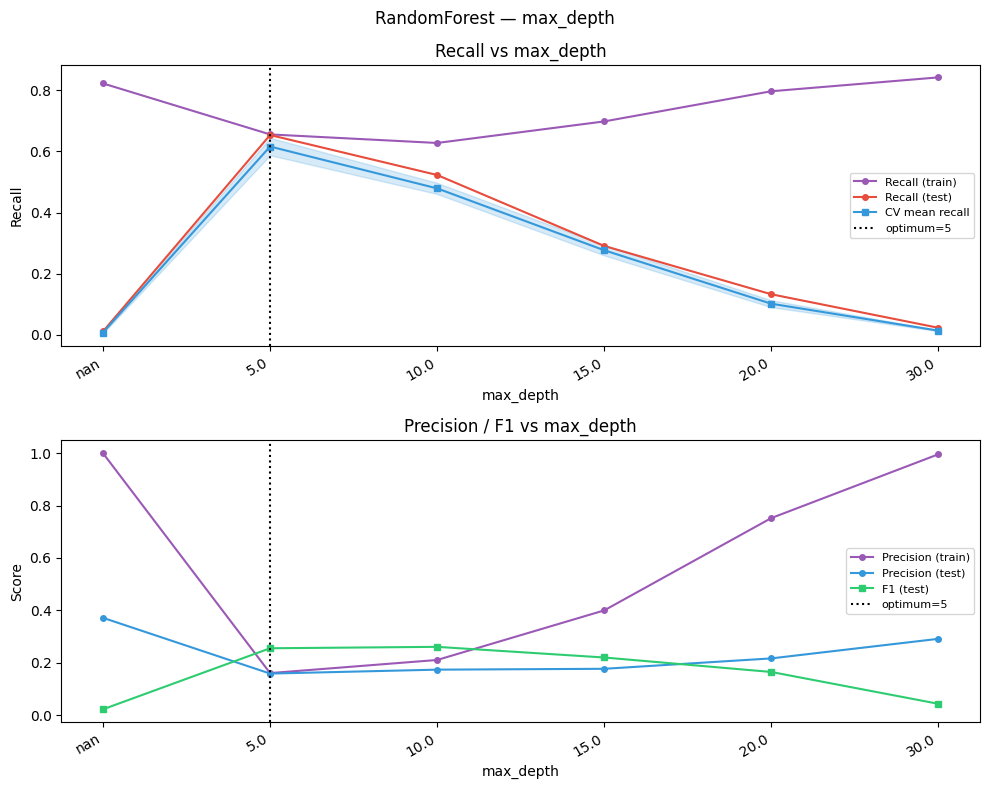

Najlepsze max_depth: 5


In [ ]:
df_rf_d = sweep_param(
    lambda **kw: RandomForestClassifier(n_estimators=best_rf_n, class_weight='balanced',
                                        n_jobs=-1, **kw),
    'max_depth', [None, 5, 10, 15, 20, 30],
    X_tr, y_tr, X_te, y_te
)
best_rf_d = plot_sweep(df_rf_d, 'max_depth', 'RandomForest — max_depth')
print(f'Najlepsze max_depth: {best_rf_d}')

max_features:   0%|          | 0/6 [00:00<?, ?it/s]

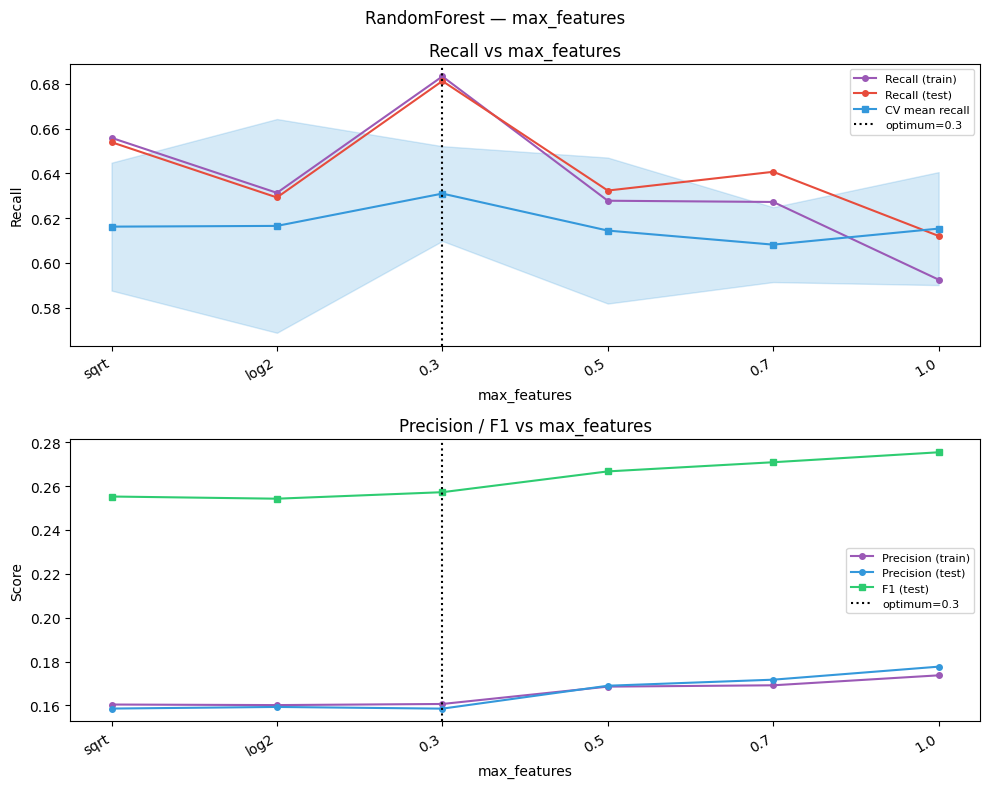

Najlepsze max_features: 0.3


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true

In [ ]:
df_rf_f = sweep_param(
    lambda **kw: RandomForestClassifier(n_estimators=best_rf_n, max_depth=best_rf_d,
                                        class_weight='balanced', n_jobs=-1, **kw),
    'max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0],
    X_tr, y_tr, X_te, y_te
)
best_rf_f = plot_sweep(df_rf_f, 'max_features', 'RandomForest — max_features')
print(f'Najlepsze max_features: {best_rf_f}')

clf_rf_best = RandomForestClassifier(
    n_estimators=best_rf_n, max_depth=best_rf_d, max_features=best_rf_f,
    class_weight='balanced', n_jobs=-1
)
clf_rf_best.fit(X_tr, y_tr)

### 3.2 AdaBoost

n_estimators:   0%|          | 0/6 [00:00<?, ?it/s]

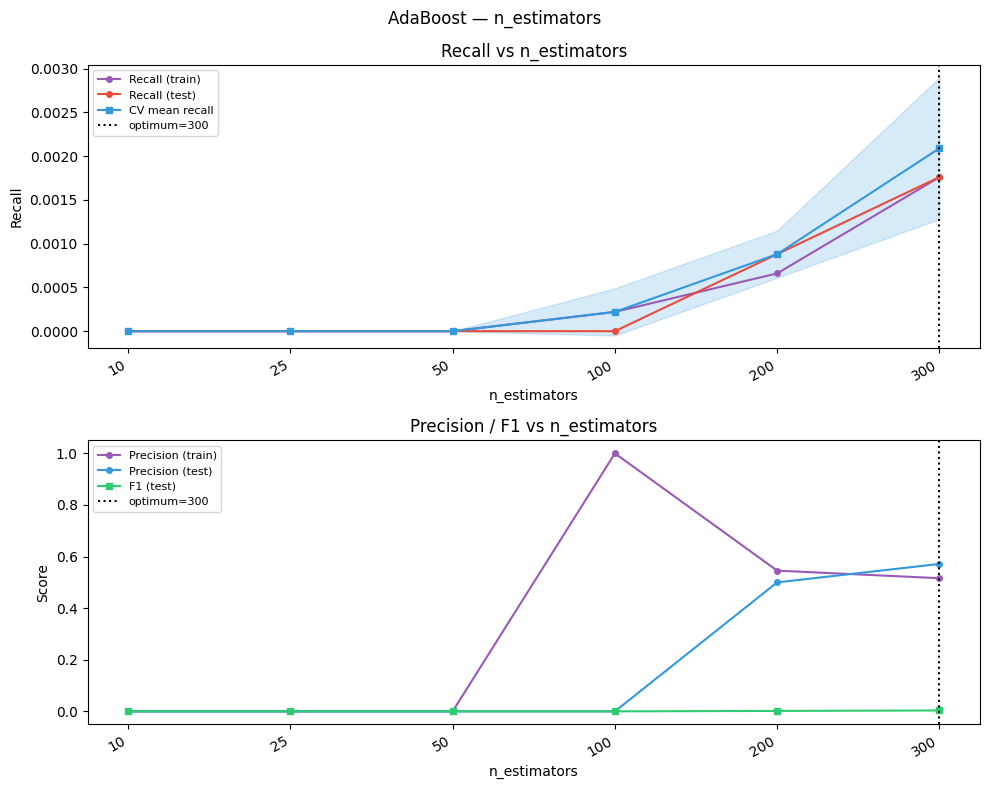

Najlepsze n_estimators: 300


In [ ]:
ada_fn = lambda **kw: AdaBoostClassifier(**kw)

df_ada_n = sweep_param(ada_fn, 'n_estimators', [10, 25, 50, 100, 200, 300],
                       X_tr, y_tr, X_te, y_te)
best_ada_n = plot_sweep(df_ada_n, 'n_estimators', 'AdaBoost — n_estimators')
print(f'Najlepsze n_estimators: {best_ada_n}')

learning_rate:   0%|          | 0/7 [00:00<?, ?it/s]

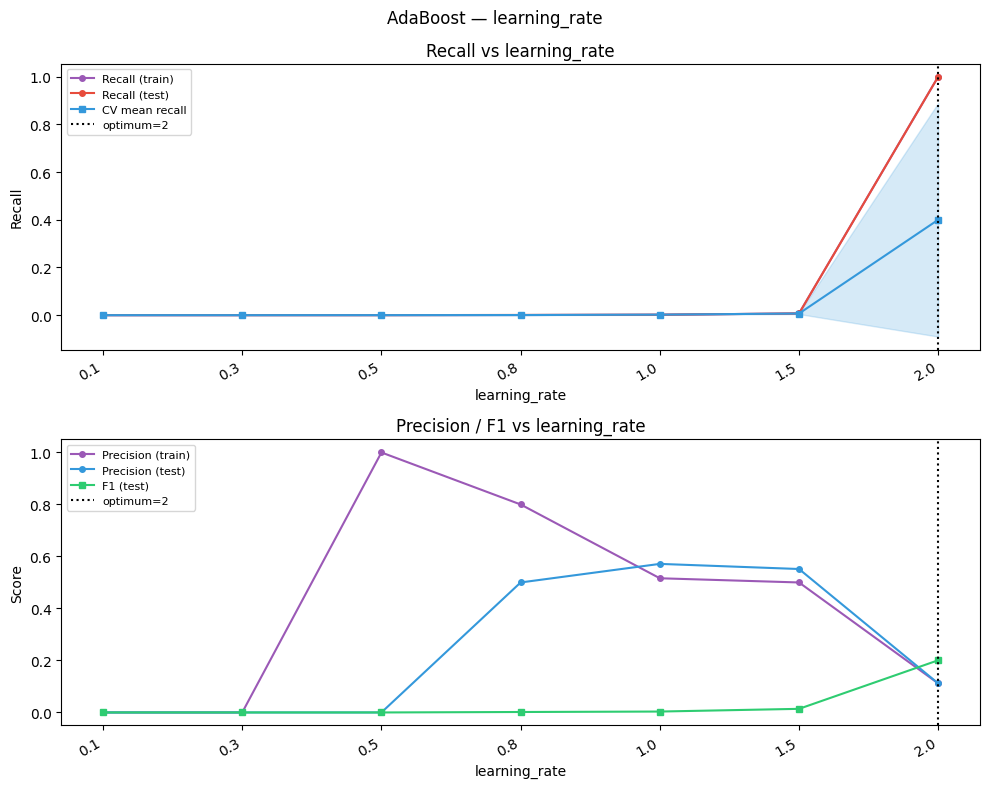

Najlepsze learning_rate: 2


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",300
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [ ]:
df_ada_lr = sweep_param(
    lambda **kw: AdaBoostClassifier(n_estimators=best_ada_n,**kw),
    'learning_rate', [0.1, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0],
    X_tr, y_tr, X_te, y_te
)
best_ada_lr = plot_sweep(df_ada_lr, 'learning_rate', 'AdaBoost — learning_rate')
print(f'Najlepsze learning_rate: {best_ada_lr}')

clf_ada_best = AdaBoostClassifier(
    n_estimators=best_ada_n, learning_rate=best_ada_lr
)
clf_ada_best.fit(X_tr, y_tr)

### 3.3 LightGBM

num_leaves:   0%|          | 0/5 [00:00<?, ?it/s]

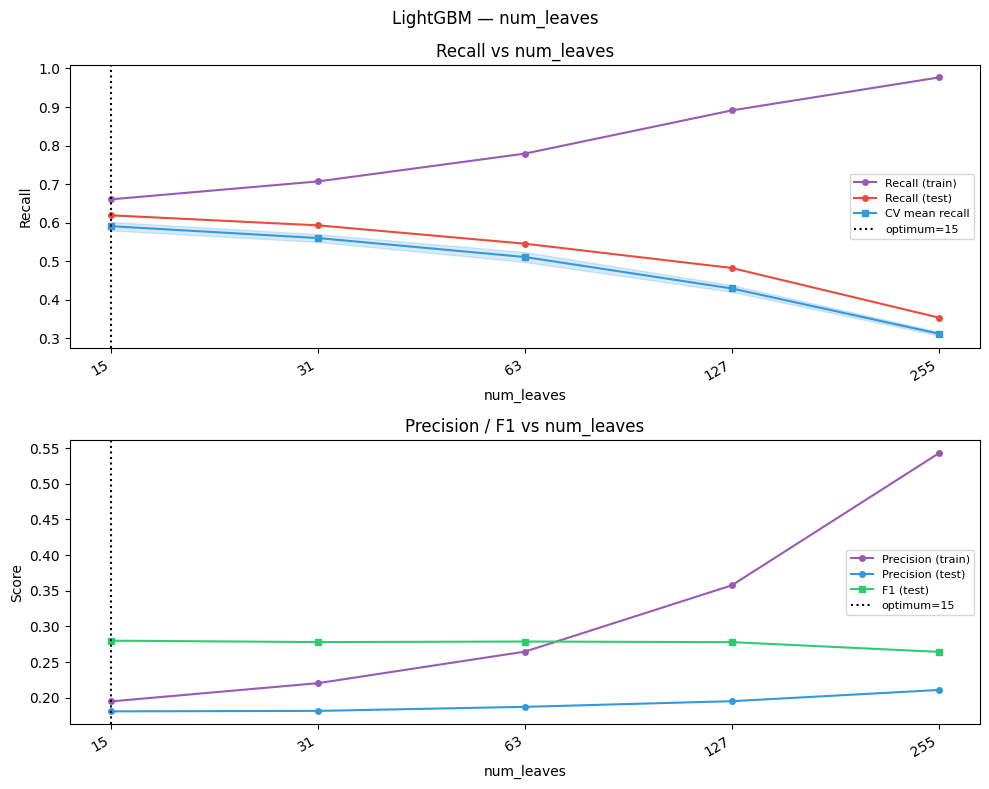

Najlepsze num_leaves: 15


In [ ]:
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
lgbm_fn = lambda **kw: lgb.LGBMClassifier(
    scale_pos_weight=pos_weight,verbose=-1, **kw
)

df_lgbm_nl = sweep_param(lgbm_fn, 'num_leaves', [15, 31, 63, 127, 255],
                         X_tr, y_tr, X_te, y_te)
best_lgbm_nl = plot_sweep(df_lgbm_nl, 'num_leaves', 'LightGBM — num_leaves')
print(f'Najlepsze num_leaves: {best_lgbm_nl}')

learning_rate:   0%|          | 0/6 [00:00<?, ?it/s]

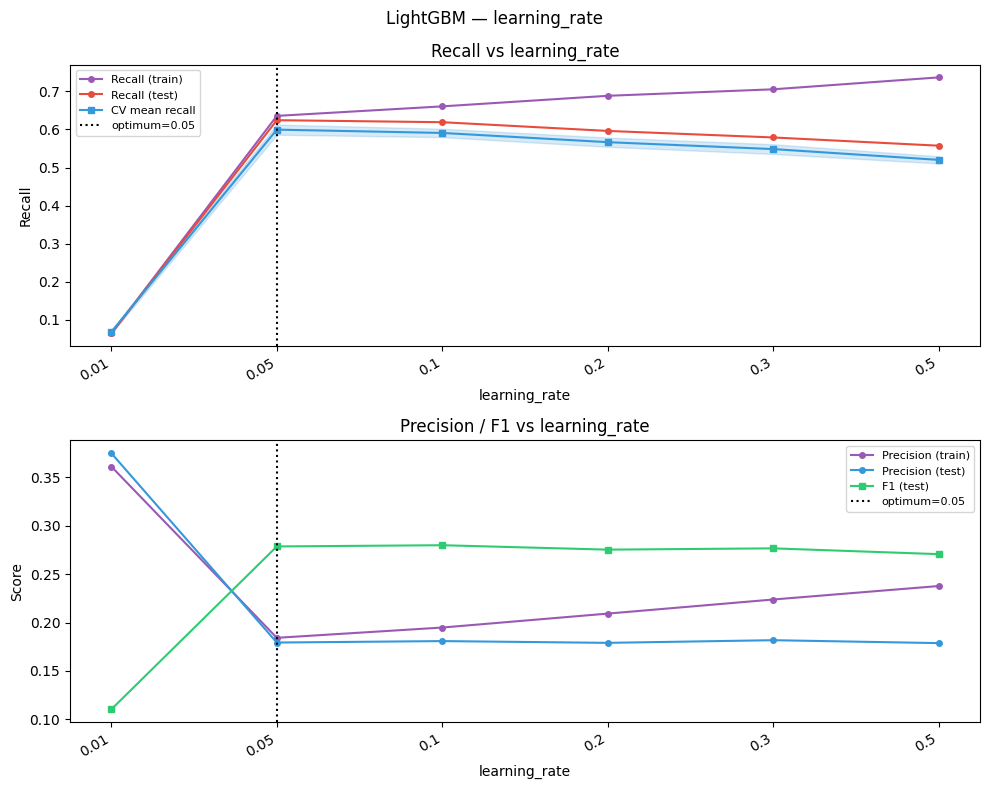

Najlepsze learning_rate: 0.05


In [ ]:
df_lgbm_lr = sweep_param(
    lambda **kw: lgb.LGBMClassifier(num_leaves=best_lgbm_nl, scale_pos_weight=pos_weight, verbose=-1, **kw),
    'learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
    X_tr, y_tr, X_te, y_te
)
best_lgbm_lr = plot_sweep(df_lgbm_lr, 'learning_rate', 'LightGBM — learning_rate')
print(f'Najlepsze learning_rate: {best_lgbm_lr}')

min_child_samples:   0%|          | 0/6 [00:00<?, ?it/s]

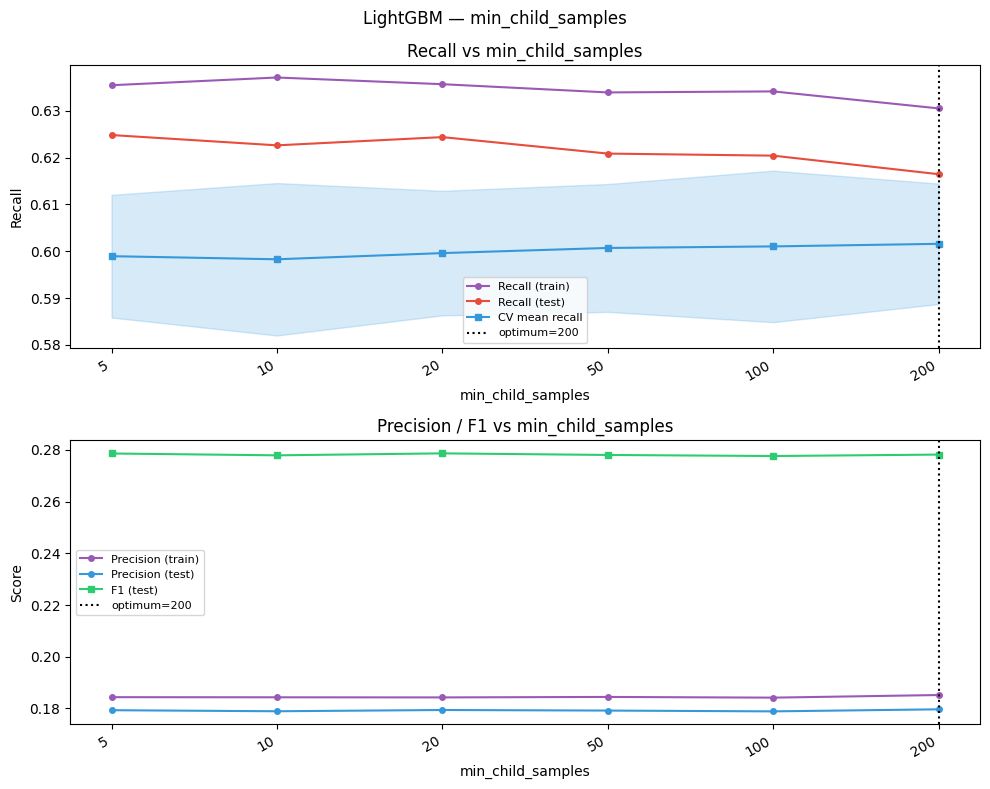

Najlepsze min_child_samples: 200


,boosting_type,'gbdt'
,num_leaves,15
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,200


In [ ]:
df_lgbm_mc = sweep_param(
    lambda **kw: lgb.LGBMClassifier(num_leaves=best_lgbm_nl, learning_rate=best_lgbm_lr,
                                    scale_pos_weight=pos_weight,verbose=-1, **kw),
    'min_child_samples', [5, 10, 20, 50, 100, 200],
    X_tr, y_tr, X_te, y_te
)
best_lgbm_mc = plot_sweep(df_lgbm_mc, 'min_child_samples', 'LightGBM — min_child_samples')
print(f'Najlepsze min_child_samples: {best_lgbm_mc}')

clf_lgbm_best = lgb.LGBMClassifier(
    num_leaves=best_lgbm_nl, learning_rate=best_lgbm_lr, min_child_samples=best_lgbm_mc,
    scale_pos_weight=pos_weight, verbose=-1
)
clf_lgbm_best.fit(X_tr, y_tr)

### 3.4 XGBoost

max_depth:   0%|          | 0/6 [00:00<?, ?it/s]

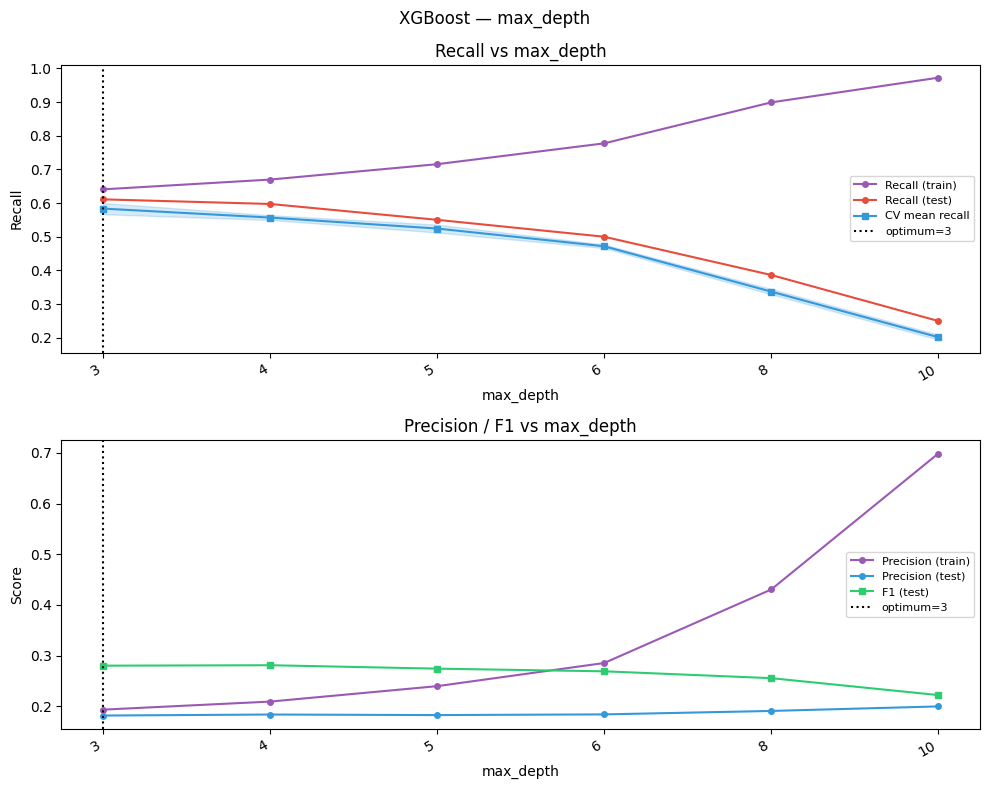

Najlepsze max_depth: 3


In [ ]:
xgb_fn = lambda **kw: xgb.XGBClassifier(
    scale_pos_weight=pos_weight, verbosity=0,
    eval_metric='logloss', **kw
)

df_xgb_d = sweep_param(xgb_fn, 'max_depth', [3, 4, 5, 6, 8, 10],
                       X_tr, y_tr, X_te, y_te)
best_xgb_d = plot_sweep(df_xgb_d, 'max_depth', 'XGBoost — max_depth')
print(f'Najlepsze max_depth: {best_xgb_d}')

learning_rate:   0%|          | 0/6 [00:00<?, ?it/s]

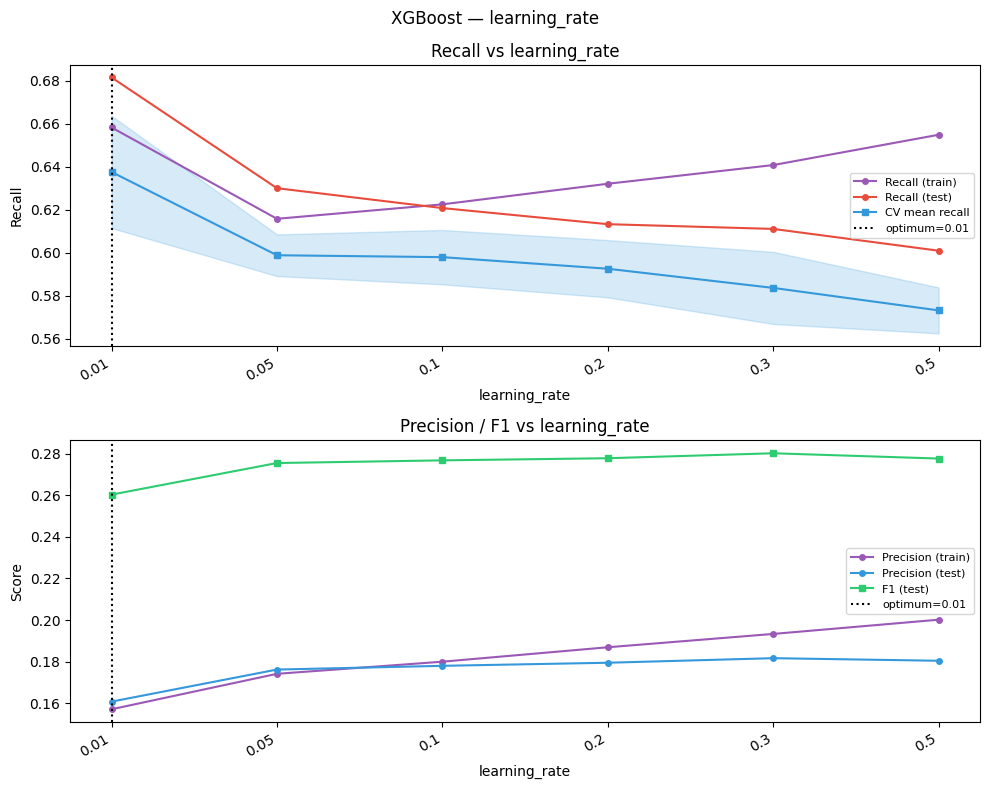

Najlepsze learning_rate: 0.01


In [ ]:
df_xgb_lr = sweep_param(
    lambda **kw: xgb.XGBClassifier(max_depth=best_xgb_d, scale_pos_weight=pos_weight, verbosity=0, eval_metric='logloss', **kw),
    'learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
    X_tr, y_tr, X_te, y_te
)
best_xgb_lr = plot_sweep(df_xgb_lr, 'learning_rate', 'XGBoost — learning_rate')
print(f'Najlepsze learning_rate: {best_xgb_lr}')

subsample:   0%|          | 0/6 [00:00<?, ?it/s]

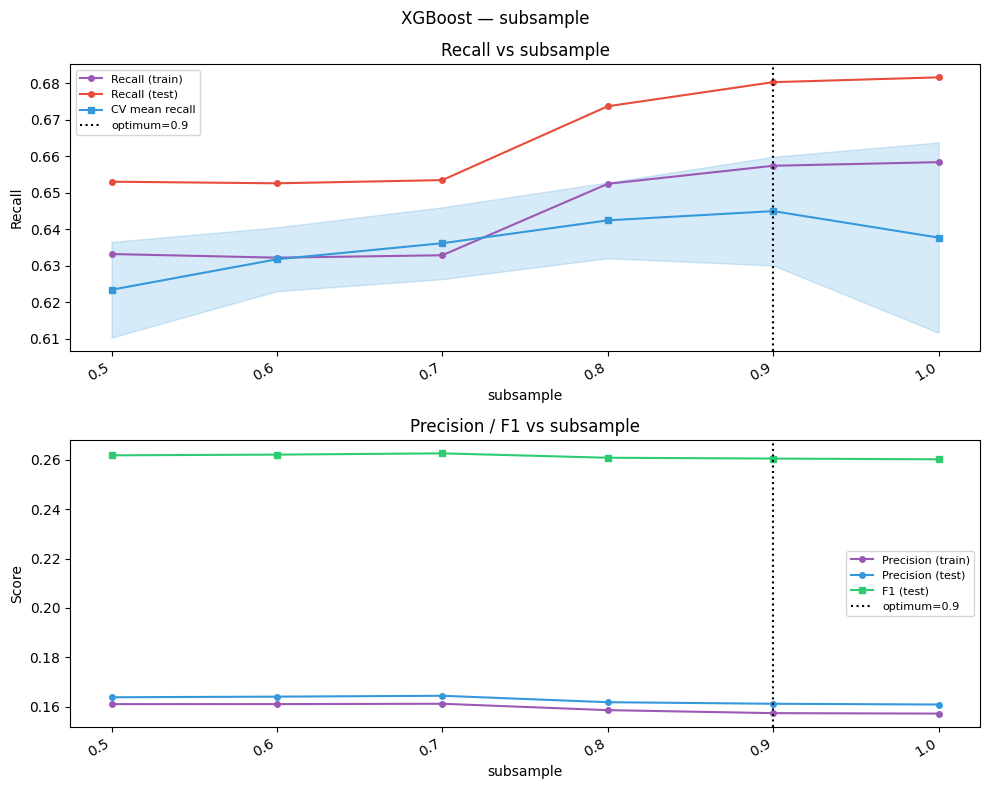

Najlepsze subsample: 0.9


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
df_xgb_ss = sweep_param(
    lambda **kw: xgb.XGBClassifier(max_depth=best_xgb_d, learning_rate=best_xgb_lr,
                                   scale_pos_weight=pos_weight,
                                   verbosity=0, eval_metric='logloss', **kw),
    'subsample', [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    X_tr, y_tr, X_te, y_te
)
best_xgb_ss = plot_sweep(df_xgb_ss, 'subsample', 'XGBoost — subsample')
print(f'Najlepsze subsample: {best_xgb_ss}')

clf_xgb_best = xgb.XGBClassifier(
    max_depth=best_xgb_d, learning_rate=best_xgb_lr, subsample=best_xgb_ss,
    scale_pos_weight=pos_weight, verbosity=0, eval_metric='logloss'
)
clf_xgb_best.fit(X_tr, y_tr)

## 4. Analiza działania zespołów klasyfikatorów

### 4.1 Skuteczność — porównanie najlepszych konfiguracji

In [ ]:
def full_eval(name, clf, X_te, y_te):
    yp = clf.predict(X_te)
    return {
        'Model':     name,
        'Recall':    recall_score(y_te, yp, zero_division=0),
        'Precision': precision_score(y_te, yp, zero_division=0),
        'F1':        f1_score(y_te, yp, zero_division=0),
        'Accuracy':  accuracy_score(y_te, yp),
        'Bal.Acc':   balanced_accuracy_score(y_te, yp),
    }

best_models = [
    ('RandomForest', clf_rf_best),
    ('AdaBoost',     clf_ada_best),
    ('LightGBM',     clf_lgbm_best),
    ('XGBoost',      clf_xgb_best),
]

df_perf = pd.DataFrame([full_eval(n, m, X_te, y_te) for n, m in best_models]).set_index('Model')
display(df_perf.round(4))

,Recall,Precision,F1,Accuracy,Bal.Acc
Model,,,,,
RandomForest,0.6812,0.1585,0.2572,0.5610,0.6135
AdaBoost,1.0000,0.1116,0.2008,0.1116,0.5000
LightGBM,0.6165,0.1796,0.2782,0.6431,0.6315
XGBoost,0.6803,0.1611,0.2606,0.5692,0.6178


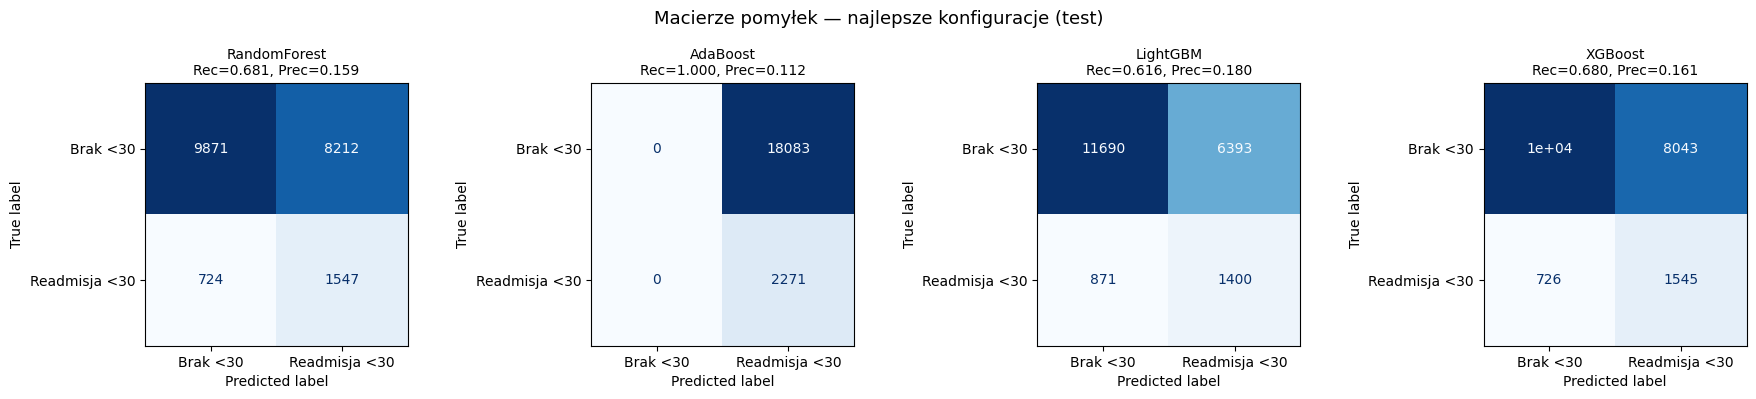

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, clf) in zip(axes, best_models):
    yp = clf.predict(X_te)
    cm = confusion_matrix(y_te, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Brak <30', 'Readmisja <30'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    r = recall_score(y_te, yp, zero_division=0)
    p = precision_score(y_te, yp, zero_division=0)
    ax.set_title(f'{name}\nRec={r:.3f}, Prec={p:.3f}', fontsize=10)
plt.suptitle('Macierze pomyłek — najlepsze konfiguracje (test)', fontsize=13)
plt.tight_layout()
plt.show()

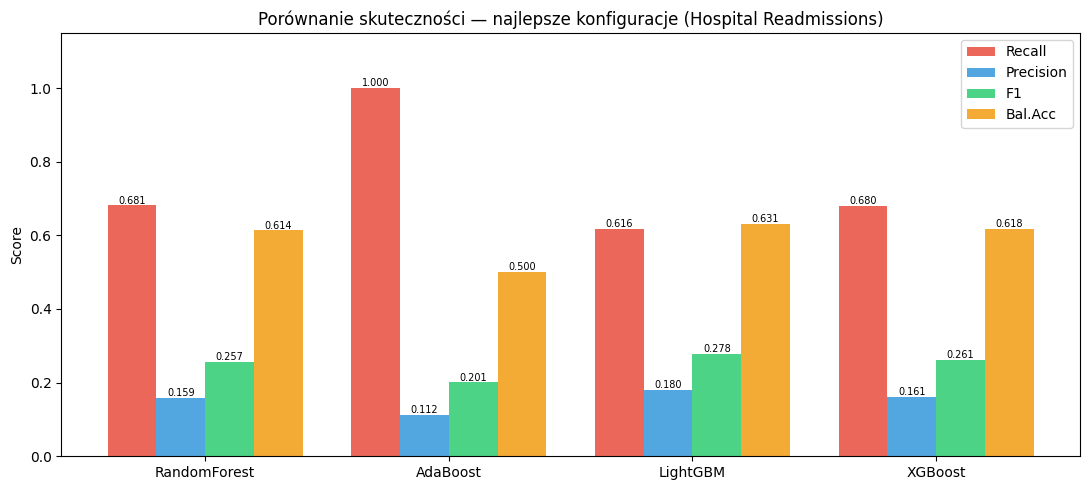

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
metrics = ['Recall', 'Precision', 'F1', 'Bal.Acc']
x = np.arange(len(df_perf))
width = 0.2
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (i - 1.5) * width, df_perf[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(df_perf.index)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Porównanie skuteczności — najlepsze konfiguracje (Hospital Readmissions)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Zrozumiałość — SHAP

In [ ]:
explainer_lgbm = shap.TreeExplainer(clf_lgbm_best)

sample_size = min(2000, X_te.shape[0])
rng = np.random.default_rng(42)
idx_sample = rng.choice(X_te.shape[0], sample_size, replace=False)
X_shap = X_te[idx_sample]

shap_values = explainer_lgbm.shap_values(X_shap)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

feat_names = [c for c in df_prep[feat_cols].columns]
print(f'SHAP values shape: {sv.shape}')

SHAP values shape: (2000, 44)


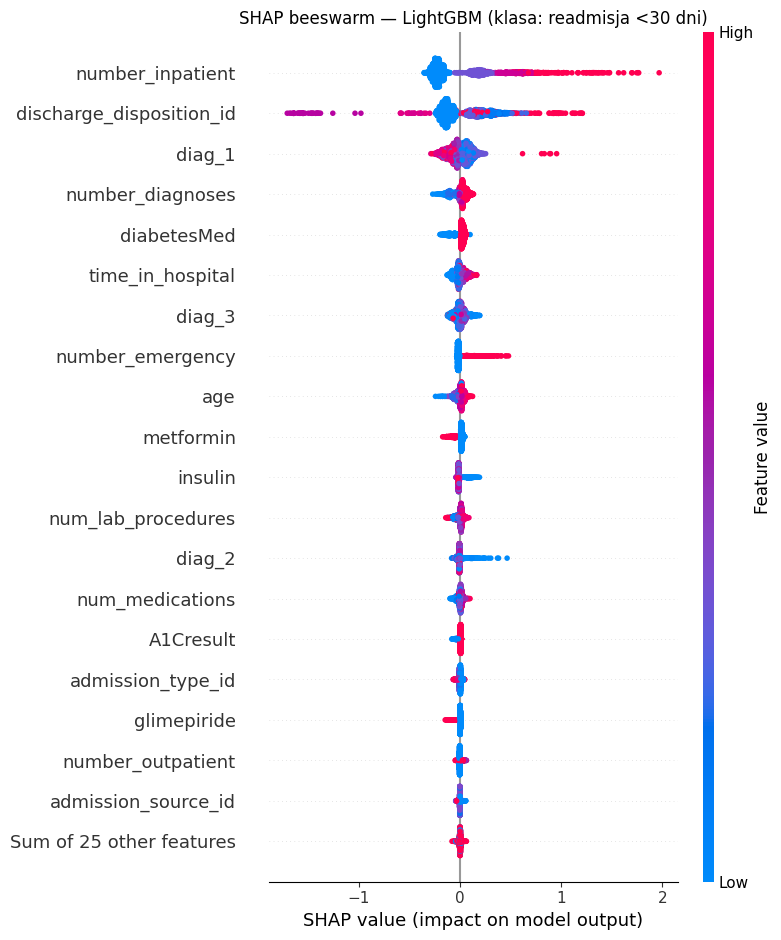

In [ ]:
shap_exp = shap.Explanation(values=sv, data=X_shap, feature_names=feat_names)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_exp, max_display=20, show=False)
plt.title('SHAP beeswarm — LightGBM (klasa: readmisja <30 dni)', fontsize=12)
plt.tight_layout()
plt.show()

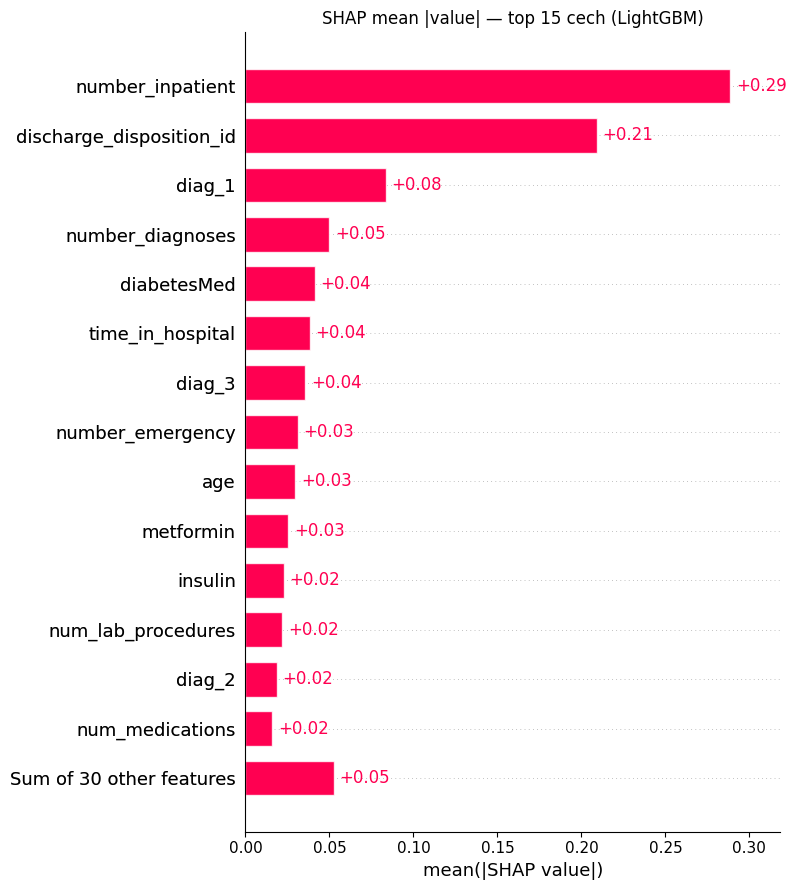

In [ ]:
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title('SHAP mean |value| — top 15 cech (LightGBM)', fontsize=12)
plt.tight_layout()
plt.show()

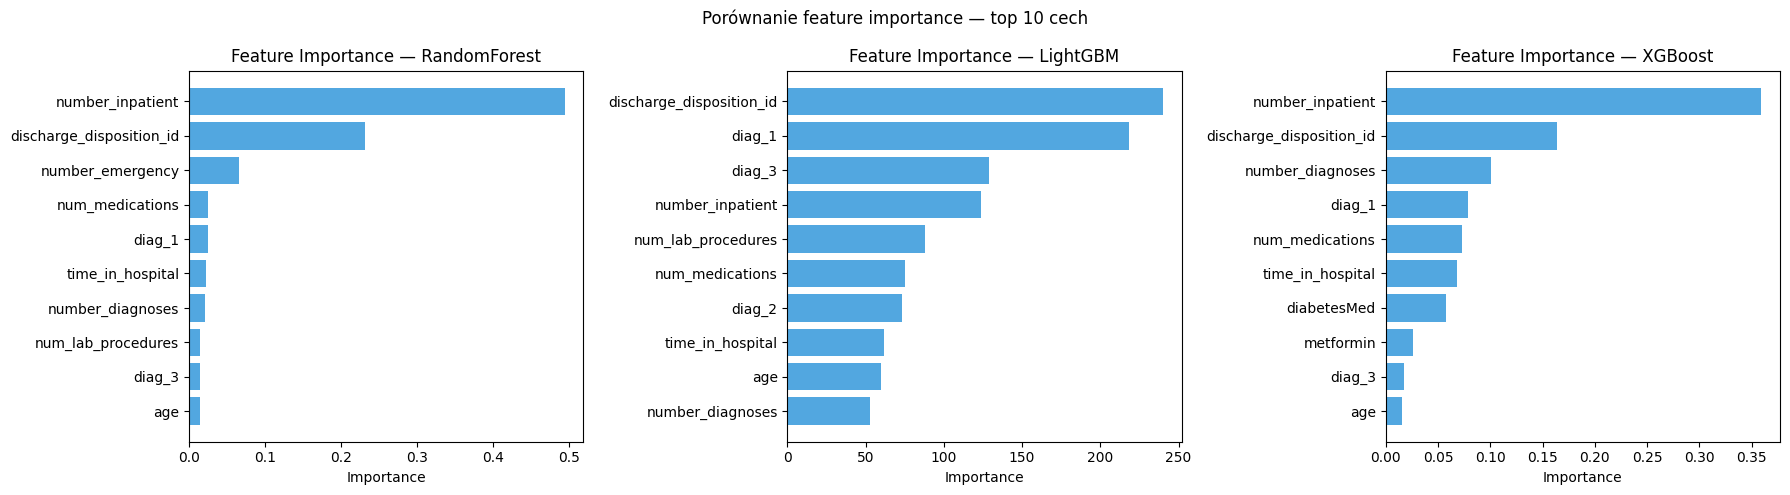

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, [('RandomForest', clf_rf_best),
                                   ('LightGBM', clf_lgbm_best),
                                   ('XGBoost', clf_xgb_best)]):
    imp = clf.feature_importances_
    top10_idx = np.argsort(imp)[-10:][::-1]
    ax.barh([feat_names[i] for i in top10_idx][::-1],
            imp[top10_idx][::-1],
            color='#3498db', alpha=0.85)
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance')

plt.suptitle('Porównanie feature importance — top 10 cech', fontsize=12)
plt.tight_layout()
plt.show()

### 4.3 Sprawiedliwość (Fairness) — Equal Opportunity

In [ ]:
def equal_opportunity(clf, X_te, y_te, sensitive_col, sensitive_values, model_name):
    """Recall (True Positive Rate) per group — equal opportunity metric."""
    yp = clf.predict(X_te)
    rows = []
    for grp in sensitive_values:
        mask = sensitive_col == grp
        if mask.sum() == 0 or y_te[mask].sum() == 0:
            continue
        rec  = recall_score(y_te[mask], yp[mask], zero_division=0)
        prec = precision_score(y_te[mask], yp[mask], zero_division=0)
        f1   = f1_score(y_te[mask], yp[mask], zero_division=0)
        rows.append({'Grupa': grp, 'Recall': rec, 'Precision': prec, 'F1': f1,
                     'N': mask.sum(), 'N_pos': y_te[mask].sum()})
    df_fair = pd.DataFrame(rows).set_index('Grupa')
    print(f'\n=== {model_name} ==='); display(df_fair.round(4))
    return df_fair


race_values  = df_sens_te['race'].unique()
gender_values = df_sens_te['gender'].unique()

print('--- Fairness wg RACE ---')
fair_race = {}
for name, clf in best_models:
    fair_race[name] = equal_opportunity(
        clf, X_te, y_te, df_sens_te['race'].values, race_values, name
    )

--- Fairness wg RACE ---

=== RandomForest ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
Caucasian,0.6884,0.1584,0.2575,15223,1717
AfricanAmerican,0.6597,0.1567,0.2532,3866,432
Hispanic,0.7800,0.2407,0.3679,404,50
Other,0.6500,0.1275,0.2131,276,20
Asian,0.4000,0.0833,0.1379,123,10



=== AdaBoost ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
Caucasian,1.0000,0.1128,0.2027,15223,1717
AfricanAmerican,1.0000,0.1117,0.2010,3866,432
Hispanic,1.0000,0.1238,0.2203,404,50
Other,1.0000,0.0725,0.1351,276,20
Asian,1.0000,0.0813,0.1504,123,10



=== LightGBM ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
Caucasian,0.6261,0.1815,0.2814,15223,1717
AfricanAmerican,0.6019,0.1733,0.2692,3866,432
Hispanic,0.6400,0.2500,0.3596,404,50
Other,0.4500,0.1154,0.1837,276,20
Asian,0.3000,0.0833,0.1304,123,10



=== XGBoost ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
Caucasian,0.6896,0.1618,0.2621,15223,1717
AfricanAmerican,0.6574,0.1587,0.2556,3866,432
Hispanic,0.7000,0.2288,0.3448,404,50
Other,0.7000,0.1308,0.2205,276,20
Asian,0.4000,0.0833,0.1379,123,10


In [ ]:
print('--- Fairness wg GENDER ---')
fair_gender = {}
for name, clf in best_models:
    fair_gender[name] = equal_opportunity(
        clf, X_te, y_te, df_sens_te['gender'].values, gender_values, name
    )

--- Fairness wg GENDER ---

=== RandomForest ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
Female,0.7036,0.1632,0.2649,10924,1255
Male,0.6535,0.1527,0.2476,9430,1016



=== AdaBoost ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
Female,1.0000,0.1149,0.2061,10924,1255
Male,1.0000,0.1077,0.1945,9430,1016



=== LightGBM ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
Female,0.6319,0.1843,0.2854,10924,1255
Male,0.5974,0.1739,0.2694,9430,1016



=== XGBoost ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
Female,0.7028,0.1652,0.2676,10924,1255
Male,0.6526,0.1560,0.2518,9430,1016


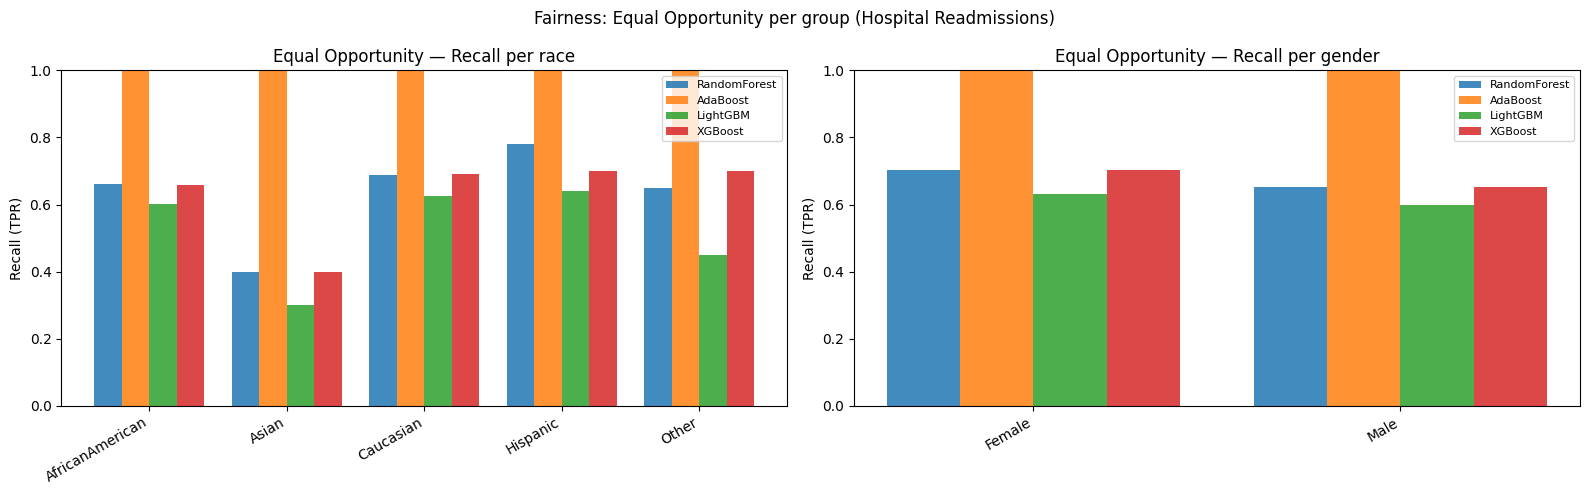

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (fair_dict, attr) in zip(axes, [(fair_race, 'race'), (fair_gender, 'gender')]):
    all_groups = sorted(set(g for df_f in fair_dict.values() for g in df_f.index))
    x = np.arange(len(all_groups))
    width = 0.2
    for i, (name, df_f) in enumerate(fair_dict.items()):
        vals = [df_f.loc[g, 'Recall'] if g in df_f.index else 0 for g in all_groups]
        ax.bar(x + (i - 1.5) * width, vals, width, label=name, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(all_groups, rotation=30, ha='right')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Recall (TPR)')
    ax.set_title(f'Equal Opportunity — Recall per {attr}')
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('Fairness: Equal Opportunity per group (Hospital Readmissions)', fontsize=12)
plt.tight_layout()
plt.show()

### Sprawdzenie wieku

--- Fairness wg AGE ---

=== RandomForest ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
[90-100),0.6102,0.1259,0.2087,581,59
[20-30),0.7857,0.3173,0.4521,307,42
[40-50),0.6355,0.1886,0.2909,2008,214
[80-90),0.7677,0.1524,0.2543,3292,409
[50-60),0.6478,0.1591,0.2554,3493,335
[60-70),0.6599,0.1608,0.2586,4531,494
[70-80),0.6970,0.1587,0.2586,5225,627
[30-40),0.6747,0.2188,0.3304,725,83
[10-20),0.5000,0.1739,0.2581,158,8



=== AdaBoost ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
[90-100),1.0000,0.1015,0.1844,581,59
[20-30),1.0000,0.1368,0.2407,307,42
[40-50),1.0000,0.1066,0.1926,2008,214
[80-90),1.0000,0.1242,0.2210,3292,409
[50-60),1.0000,0.0959,0.1750,3493,335
[60-70),1.0000,0.1090,0.1966,4531,494
[70-80),1.0000,0.1200,0.2143,5225,627
[30-40),1.0000,0.1145,0.2054,725,83
[10-20),1.0000,0.0506,0.0964,158,8



=== LightGBM ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
[90-100),0.6271,0.1407,0.2298,581,59
[20-30),0.8095,0.3333,0.4722,307,42
[40-50),0.6121,0.2194,0.3231,2008,214
[80-90),0.6797,0.1757,0.2793,3292,409
[50-60),0.6269,0.1944,0.2968,3493,335
[60-70),0.6215,0.1933,0.2949,4531,494
[70-80),0.6396,0.1823,0.2837,5225,627
[30-40),0.6386,0.2345,0.3430,725,83
[10-20),0.6250,0.2083,0.3125,158,8



=== XGBoost ===


,Recall,Precision,F1,N,N_pos
Grupa,,,,,
[90-100),0.7627,0.1160,0.2013,581,59
[20-30),0.8571,0.2880,0.4311,307,42
[40-50),0.6308,0.1834,0.2842,2008,214
[80-90),0.7066,0.1478,0.2445,3292,409
[50-60),0.6239,0.1529,0.2456,3493,335
[60-70),0.6336,0.1606,0.2562,4531,494
[70-80),0.6715,0.1604,0.2590,5225,627
[30-40),0.7108,0.2115,0.3260,725,83
[10-20),0.7500,0.1333,0.2264,158,8


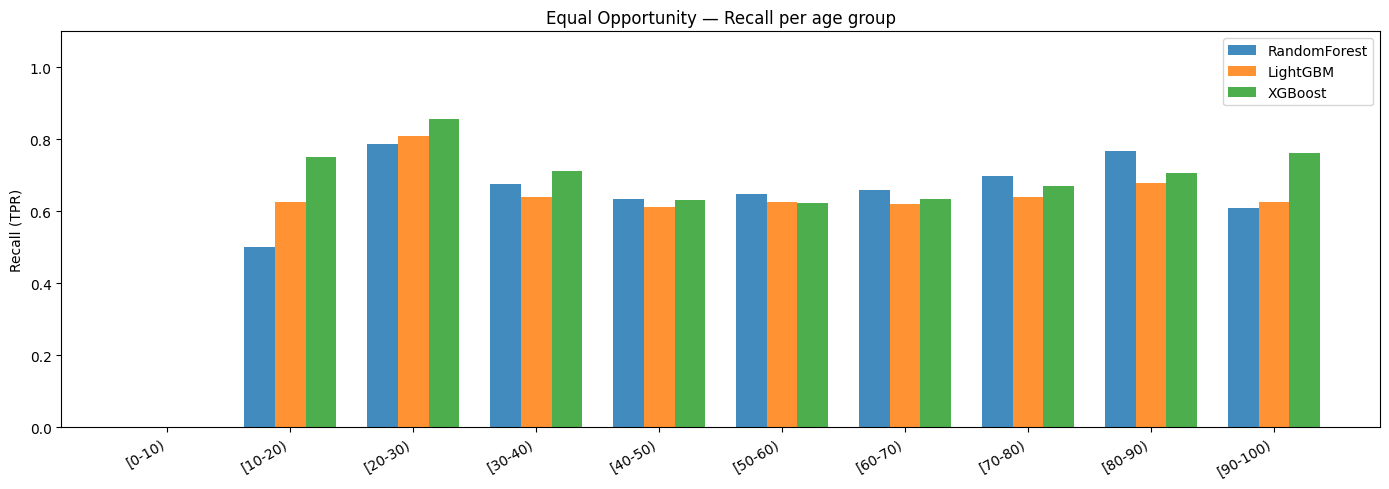

In [ ]:
df_sens_te_age = df_prep[['age']].iloc[idx_te].reset_index(drop=True)

age_values = df_sens_te_age['age'].unique()
print('--- Fairness wg AGE ---')
fair_age = {}
for name, clf in best_models:
    fair_age[name] = equal_opportunity(
        clf, X_te, y_te, df_sens_te_age['age'].values, age_values, name
    )

best_models_no_ada = [(name, clf) for name, clf in best_models if name != 'AdaBoost']

fig, ax = plt.subplots(figsize=(14, 5))

all_groups = sorted(df_sens_te_age['age'].dropna().unique())
x = np.arange(len(all_groups))
width = 0.25

for i, (name, clf) in enumerate(best_models_no_ada):
    vals = [fair_age[name].loc[g, 'Recall'] if g in fair_age[name].index else 0 for g in all_groups]
    ax.bar(x + (i - 1) * width, vals, width, label=name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(all_groups, rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Recall (TPR)')
ax.set_title('Equal Opportunity — Recall per age group')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Eksperyment socjotechniczny: co jeśli...?

In [ ]:
feat_list = [c for c in df_prep[feat_cols].columns]
try:
    race_col_idx = feat_list.index('race')
    race_available = True
    print(f'Kolumna race to indeks {race_col_idx}')
except ValueError:
    race_available = False
    print('Kolumna race nie jest w zbiorze cech (została usunięta podczas preprocessingu)')

Kolumna race to indeks 0


In [ ]:
if race_available:
    le_race = LabelEncoder()
    le_race.fit(df_raw['race'].astype(str))
    caucasian_code = le_race.transform(['Caucasian'])[0]

    X_te_caucasian = X_te.copy()
    X_te_caucasian[:, race_col_idx] = caucasian_code

    print(f'\nKod Caucasian: {caucasian_code}')
    print('\nRóżnica predykcji (% zmienionych) po przestawieniu race=Caucasian:')
    print(f'{"Model":<15} {"Zmienione":>12} {"Recall oryg":>12} {"Recall caucasian":>18}')
    print('-' * 60)
    for name, clf in best_models:
        yp_orig = clf.predict(X_te)
        yp_cauc = clf.predict(X_te_caucasian)
        changed = (yp_orig != yp_cauc).mean() * 100
        rec_orig = recall_score(y_te, yp_orig, zero_division=0)
        rec_cauc = recall_score(y_te, yp_cauc, zero_division=0)
        print(f'{name:<15} {changed:>11.2f}% {rec_orig:>12.4f} {rec_cauc:>18.4f}')
else:
    print('Race nie wchodzi w skład cech — eksperyment na gender')
    # Znajdź gender
    try:
        gender_col_idx = feat_list.index('gender')
        le_gender = LabelEncoder()
        le_gender.fit(df_raw['gender'].astype(str))
        male_code = le_gender.transform(['Male'])[0]

        X_te_male = X_te.copy()
        X_te_male[:, gender_col_idx] = male_code

        print('Różnica predykcji po przestawieniu gender=Male:')
        for name, clf in best_models:
            yp_orig = clf.predict(X_te)
            yp_male = clf.predict(X_te_male)
            changed = (yp_orig != yp_male).mean() * 100
            print(f'{name}: {changed:.2f}% zmienionych predykcji')
    except ValueError:
        print('Gender też niedostępne — race i gender zostały pominięte w preprocessingu')


Kod Caucasian: 2

Różnica predykcji (% zmienionych) po przestawieniu race=Caucasian:
Model              Zmienione  Recall oryg   Recall caucasian
------------------------------------------------------------
RandomForest           0.07%       0.6812             0.6816
AdaBoost               0.00%       1.0000             1.0000
LightGBM               0.07%       0.6165             0.6169
XGBoost                0.00%       0.6803             0.6803


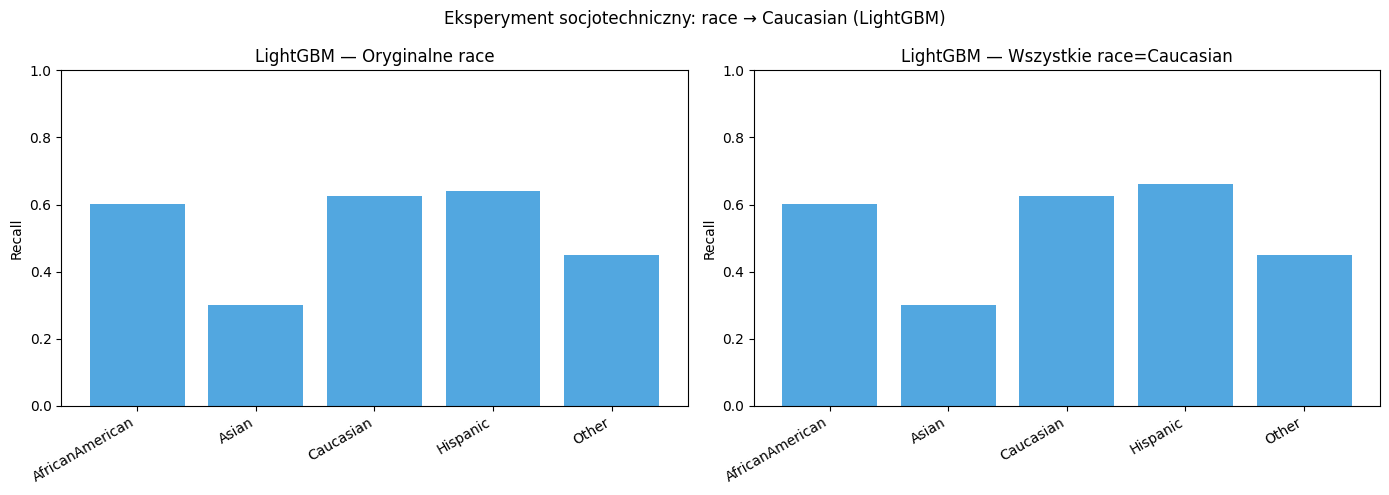

In [ ]:
if race_available:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (X_eval, label) in zip(axes, [(X_te, 'Oryginalne race'),
                                           (X_te_caucasian, 'Wszystkie race=Caucasian')]):
        yp = clf_lgbm_best.predict(X_eval)
        recalls = []
        groups = sorted(df_sens_te['race'].dropna().unique())
        for grp in groups:
            mask = df_sens_te['race'].values == grp
            if mask.sum() > 0 and y_te[mask].sum() > 0:
                recalls.append(recall_score(y_te[mask], yp[mask], zero_division=0))
            else:
                recalls.append(0)
        ax.bar(groups, recalls, color='#3498db', alpha=0.85)
        ax.set_title(f'LightGBM — {label}')
        ax.set_ylabel('Recall')
        ax.set_ylim(0, 1.0)
        ax.set_xticklabels(groups, rotation=30, ha='right')

    plt.suptitle('Eksperyment socjotechniczny: race → Caucasian (LightGBM)', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
age_col_idx = [c for c in df_prep[feat_cols].columns].index('age')

le_age = LabelEncoder()
le_age.fit(df_raw['age'].astype(str))
old_code = le_age.transform(['[70-80)'])[0]
young_code = le_age.transform(['[20-30)'])[0]

X_te_old = X_te.copy()
X_te_old[:, age_col_idx] = old_code

X_te_young = X_te.copy()
X_te_young[:, age_col_idx] = young_code

print(f'Kod [70-80): {old_code}, Kod [20-30): {young_code}')
print('\nRóżnica predykcji po przestawieniu wieku:')
print(f'{"Model":<15} {"→ starszy (70-80)":>20} {"→ młodszy (20-30)":>20}')
print('-' * 60)
for name, clf in best_models_no_ada:
    yp_orig  = clf.predict(X_te)
    yp_old   = clf.predict(X_te_old)
    yp_young = clf.predict(X_te_young)
    changed_old   = (yp_orig != yp_old).mean() * 100
    changed_young = (yp_orig != yp_young).mean() * 100
    print(f'{name:<15} {changed_old:>19.2f}% {changed_young:>19.2f}%')

Kod [70-80): 7, Kod [20-30): 2

Różnica predykcji po przestawieniu wieku:
Model              → starszy (70-80)    → młodszy (20-30)
------------------------------------------------------------
RandomForest                   0.68%                1.16%
LightGBM                       1.73%                3.50%
XGBoost                        0.05%                0.47%


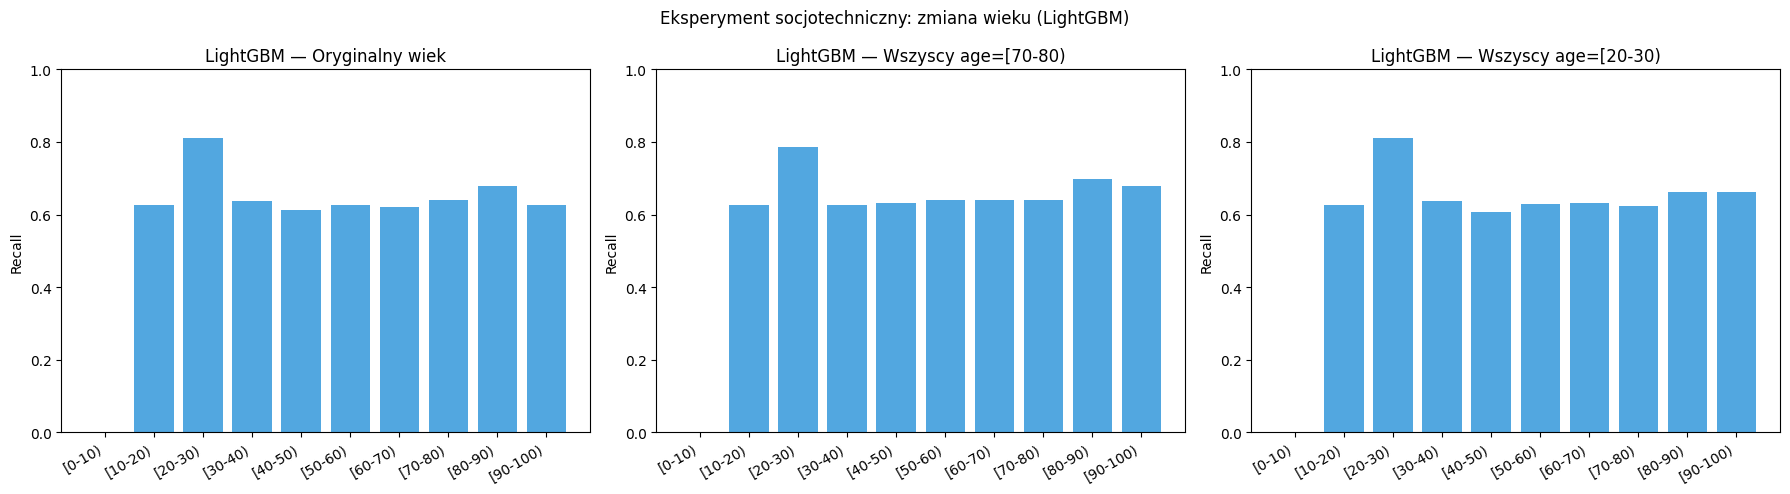

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (X_eval, label) in zip(axes, [
    (X_te,       'Oryginalny wiek'),
    (X_te_old,   'Wszyscy age=[70-80)'),
    (X_te_young, 'Wszyscy age=[20-30)'),
]):
    yp = clf_lgbm_best.predict(X_eval)
    groups = sorted(df_sens_te_age['age'].dropna().unique())
    recalls = []
    for grp in groups:
        mask = df_sens_te_age['age'].values == grp
        if mask.sum() > 0 and y_te[mask].sum() > 0:
            recalls.append(recall_score(y_te[mask], yp[mask], zero_division=0))
        else:
            recalls.append(0)
    ax.bar(groups, recalls, color='#3498db', alpha=0.85)
    ax.set_title(f'LightGBM — {label}')
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1.0)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, rotation=30, ha='right')

plt.suptitle('Eksperyment socjotechniczny: zmiana wieku (LightGBM)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Mini raport śledczy

## Mini raport śledczy — Hospital Readmissions

### Problem
Przewidywanie wczesnej readmisji pacjenta z cukrzycą (<30 dni) na podstawie
danych z 130 szpitali USA (1999–2008). Zbiór silnie nierównomierny — tylko 11.2% readmisji.

### Co było najważniejsze w predykcji?
Dwie cechy dominują (potwierdzone przez SHAP):
- **`number_inpatient`** (SHAP=0.29) — historia poprzednich hospitalizacji
- **`discharge_disposition_id`** (SHAP=0.21) — sposób wypisu ze szpitala

Pozostałe 42 cechy mają marginalny wpływ. Model jest de facto dwucechowy.

### Który model najlepszy?
| Model | Recall | F1 | Bal.Acc |
|---|---|---|---|
| RandomForest | 0.681 | 0.257 | 0.614 |
| LightGBM | 0.617 | 0.278 | 0.632 |
| XGBoost | 0.680 | 0.261 | 0.618 |
| AdaBoost | 1.000* | 0.201 | 0.500 |

*AdaBoost przewiduje wszystko jako readmisję — bezużyteczny.

RF i XGBoost mają najwyższy recall, LightGBM najlepszy balans precision/recall.

### Czy model działa sprawiedliwie?
- **Płeć** — brak biasu, recall ~0.63–0.70 dla Female i Male
- **Rasa** — potencjalny problem dla grupy Asian (recall ~0.30 vs ~0.63 dla Caucasian),
  ale grupa jest bardzo mała (~1% danych) więc estymata niepewna
- **Wiek** — brak biasu, recall stabilny dla wszystkich grup dorosłych

Eksperymenty counterfactual potwierdzają że model **ignoruje race i age** —
zmiana tych cech nie zmienia predykcji. Decyzje są kliniczne, nie demograficzne.

### Co zmienić przed wdrożeniem?
1. Obniżyć próg decyzji poniżej 0.5 — poprawi recall kosztem precision
2. Zebrać więcej danych dla grup mniejszościowych (Asian, Hispanic)
3. Zewnętrzna walidacja na danych z innego szpitala i okresu
4. Audyt etyczny: czy race/age powinny w ogóle być cechami wejściowymi?

In [ ]:
default_models = [
    ('RandomForest (default)', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)),
    ('LightGBM (default)',     lgb.LGBMClassifier(scale_pos_weight=pos_weight, verbose=-1)),
    ('XGBoost (default)',      xgb.XGBClassifier(scale_pos_weight=pos_weight, verbosity=0, eval_metric='logloss')),
]

rows = []
for name, clf in default_models:
    clf.fit(X_tr, y_tr)
    yp = clf.predict(X_te)
    rows.append({
        'Model':     name,
        'Recall':    recall_score(y_te, yp, zero_division=0),
        'Precision': precision_score(y_te, yp, zero_division=0),
        'F1':        f1_score(y_te, yp, zero_division=0),
        'Bal.Acc':   balanced_accuracy_score(y_te, yp),
    })

df_default = pd.DataFrame(rows).set_index('Model')

df_compare = pd.concat([
    df_perf.drop(columns='Accuracy').loc[['RandomForest', 'LightGBM', 'XGBoost']].rename(
        index=lambda x: f'{x} (tuned)'
    ),
    df_default
]).sort_index()

display(df_compare.round(4))